In [431]:
from pathlib import Path
import h5py
import numpy as np
import matplotlib.pyplot as plt
import time

In [449]:
import sklearn.utils as sku
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.metrics import roc_auc_score, roc_curve, log_loss, confusion_matrix, ConfusionMatrixDisplay
import lightgbm as lgbm
from lightgbm import early_stopping

import torch
from torch.utils.data import Dataset, DataLoader, Sampler
from torch import nn, optim

In [433]:
notebook_dir = Path.cwd()
h5_dir = notebook_dir / "h5" / "user.amoranch.361106.e3601_s3681_r13167_p4940.egd.electrons-cell_trial.EGAM1.25_0_63.3afd5d9_output.h5"
h5_files = sorted(path for path in h5_dir.iterdir() if path.is_file())

if not h5_files:
    raise FileNotFoundError(f"No files found in {h5_dir}")

h5_path = h5_files[np.random.randint(0, len(h5_files))]
print(f"Found {len(h5_files)} files in {h5_dir.name}")
print(f"Example file: {h5_path.name}")

Found 5 files in user.amoranch.361106.e3601_s3681_r13167_p4940.egd.electrons-cell_trial.EGAM1.25_0_63.3afd5d9_output.h5
Example file: user.amoranch.50640148._000021.output.h5


In [456]:
h5_files[:-1]

[WindowsPath('c:/Users/jonas/Desktop/Masters/Main/bridge/h5/user.amoranch.361106.e3601_s3681_r13167_p4940.egd.electrons-cell_trial.EGAM1.25_0_63.3afd5d9_output.h5/user.amoranch.50640148._000009.output.h5'),
 WindowsPath('c:/Users/jonas/Desktop/Masters/Main/bridge/h5/user.amoranch.361106.e3601_s3681_r13167_p4940.egd.electrons-cell_trial.EGAM1.25_0_63.3afd5d9_output.h5/user.amoranch.50640148._000021.output.h5'),
 WindowsPath('c:/Users/jonas/Desktop/Masters/Main/bridge/h5/user.amoranch.361106.e3601_s3681_r13167_p4940.egd.electrons-cell_trial.EGAM1.25_0_63.3afd5d9_output.h5/user.amoranch.50640148._000141.output.h5'),
 WindowsPath('c:/Users/jonas/Desktop/Masters/Main/bridge/h5/user.amoranch.361106.e3601_s3681_r13167_p4940.egd.electrons-cell_trial.EGAM1.25_0_63.3afd5d9_output.h5/user.amoranch.50640148._000184.output.h5')]

In [434]:
class H5EgammaDataset(Dataset):
    def __init__(
        self,
        files,
        y_source="truth",
        y_field="pt",
        exclude_fields=None,
    ):
        self.files = [Path(path) for path in files]
        self.y_source = y_source
        self.y_field = y_field
        self.exclude_fields = set(exclude_fields or [])
        self.handles = {}
        self.lengths = []

        for path in self.files:
            with h5py.File(path, "r") as h5_file:
                lengths = {
                    name: len(h5_file[name])
                    for name in ("egammas", "cells", "tracks")
                }
                if len(set(lengths.values())) != 1:
                    raise ValueError(f"egammas, cells and tracks are not aligned in {path}")
                self.lengths.append(lengths["egammas"])

        self.offsets = np.concatenate(([0], np.cumsum(self.lengths)))

    def __len__(self):
        return int(self.offsets[-1])

    def _get_file_and_row(self, index):
        file_index = np.searchsorted(self.offsets, index, side="right") - 1
        local_index = int(index - self.offsets[file_index])
        if file_index not in self.handles:
            self.handles[file_index] = h5py.File(self.files[file_index], "r")
        return self.handles[file_index], local_index

    @staticmethod
    def _structured_to_array(rows, exclude_fields):
        names = [name for name in rows.dtype.names if name not in exclude_fields]
        values = [np.asarray(rows[name], dtype=np.float32).reshape(-1) for name in names]
        return np.concatenate(values) if values else np.empty(0, dtype=np.float32)

    def __getitem__(self, index):
        h5_file, local_index = self._get_file_and_row(index)
        eventwise = h5_file["eventwise"]
        first_indices = eventwise["firstEgammaIndex"][:]
        event_index = int(np.searchsorted(first_indices, local_index, side="right") - 1)

        if event_index < 0 or local_index >= first_indices[event_index] + eventwise["nEgammas"][event_index]:
            raise IndexError(f"Egamma row {local_index} is not covered by eventwise")

        egamma_x = self._structured_to_array(
            h5_file["egammas"][local_index],
            self.exclude_fields,
        )
        cell_x = self._structured_to_array(
            h5_file["cells"][local_index],
            self.exclude_fields,
        )
        track_x = self._structured_to_array(
            h5_file["tracks"][local_index],
            self.exclude_fields,
        )
        event_x = self._structured_to_array(eventwise[event_index], self.exclude_fields)
        features = np.concatenate((egamma_x, cell_x, track_x, event_x))

        if self.y_source not in h5_file:
            raise KeyError(f"Unknown y source: {self.y_source}")
        target_dataset = h5_file[self.y_source]
        target_index = event_index if self.y_source == "eventwise" else local_index
        target = np.float32(target_dataset[self.y_field][target_index])

        return torch.from_numpy(features), torch.tensor(target)

    def close(self):
        for handle in self.handles.values():
            handle.close()
        self.handles.clear()

In [435]:
class H5EgammaDataset_batched(Dataset):
    def __init__(
        self,
        files,
        y_source="truth",
        y_field="pt",
        exclude_fields=None,
    ):
        self.files = [Path(path) for path in files]
        self.y_source = y_source
        self.y_field = y_field
        self.exclude_fields = set(exclude_fields or [])
        self.handles = {}
        self.lengths = []

        for path in self.files:
            with h5py.File(path, "r") as h5_file:
                lengths = {
                    name: len(h5_file[name])
                    for name in ("egammas", "cells", "tracks")
                }
                if len(set(lengths.values())) != 1:
                    raise ValueError(f"egammas, cells and tracks are not aligned in {path}")
                self.lengths.append(lengths["egammas"])

        self.offsets = np.concatenate(([0], np.cumsum(self.lengths)))

    def __len__(self):
        return int(self.offsets[-1])

    def _get_file_and_row(self, index):
        file_index = np.searchsorted(self.offsets, index, side="right") - 1
        local_index = int(index - self.offsets[file_index])
        if file_index not in self.handles:
            self.handles[file_index] = h5py.File(self.files[file_index], "r")
        return file_index, self.handles[file_index], local_index

    @staticmethod
    def _structured_to_array(rows, exclude_fields):
        names = [name for name in rows.dtype.names if name not in exclude_fields]
        values = [np.asarray(rows[name], dtype=np.float32).reshape(-1) for name in names]
        return np.concatenate(values) if values else np.empty(0, dtype=np.float32)

    @staticmethod
    def _read_aligned_rows(h5_file, indices):
        names = ("egammas", "cells", "tracks")
        indices = np.asarray(indices, dtype=np.int64)
        sort_order = np.argsort(indices)
        sorted_indices = indices[sort_order]
        runs = np.flatnonzero(np.diff(sorted_indices) > 1) + 1
        run_starts = np.r_[0, runs]
        run_ends = np.r_[runs, len(sorted_indices)]
        use_slices = len(run_starts) <= max(1, len(sorted_indices) // 2)

        if not use_slices:
            return {name: h5_file[name][sorted_indices] for name in names}, sort_order

        rows = {name: [] for name in names}
        for start, end in zip(run_starts, run_ends):
            first = int(sorted_indices[start])
            last = int(sorted_indices[end - 1]) + 1
            relative_indices = sorted_indices[start:end] - first
            for name in names:
                rows[name].append(h5_file[name][first:last][relative_indices])

        return {name: np.concatenate(rows[name]) for name in names}, sort_order

    def _read_one(self, h5_file, local_index, eventwise=None, first_indices=None, rows=None):
        if eventwise is None:
            eventwise = h5_file["eventwise"][:]
        if first_indices is None:
            first_indices = eventwise["firstEgammaIndex"]

        event_index = int(np.searchsorted(first_indices, local_index, side="right") - 1)
        if event_index < 0 or local_index >= first_indices[event_index] + eventwise["nEgammas"][event_index]:
            raise IndexError(f"Egamma row {local_index} is not covered by eventwise")

        if rows is None:
            rows = {name: h5_file[name][local_index] for name in ("egammas", "cells", "tracks")}

        features = np.concatenate((
            self._structured_to_array(rows["egammas"], self.exclude_fields),
            self._structured_to_array(rows["cells"], self.exclude_fields),
            self._structured_to_array(rows["tracks"], self.exclude_fields),
            self._structured_to_array(eventwise[event_index], self.exclude_fields),
        ))

        if self.y_source not in h5_file:
            raise KeyError(f"Unknown y source: {self.y_source}")
        target_index = event_index if self.y_source == "eventwise" else local_index
        target = np.float32(h5_file[self.y_source][self.y_field][target_index])
        return torch.from_numpy(features), torch.tensor(target)

    def __getitem__(self, index):
        _, h5_file, local_index = self._get_file_and_row(index)
        return self._read_one(h5_file, local_index)

    def __getitems__(self, indices):
        indices = list(indices)
        grouped = {}
        for output_position, index in enumerate(indices):
            file_index = int(np.searchsorted(self.offsets, index, side="right") - 1)
            local_index = int(index - self.offsets[file_index])
            grouped.setdefault(file_index, []).append((output_position, local_index))

        batch = [None] * len(indices)
        for file_index, positions in grouped.items():
            if file_index not in self.handles:
                self.handles[file_index] = h5py.File(self.files[file_index], "r")
            h5_file = self.handles[file_index]
            local_indices = np.array([local_index for _, local_index in positions])
            rows, sort_order = self._read_aligned_rows(h5_file, local_indices)
            sorted_indices = np.sort(local_indices)
            eventwise = h5_file["eventwise"][:]
            first_indices = eventwise["firstEgammaIndex"]

            for sorted_position, original_position in enumerate(np.argsort(sort_order)):
                batch[positions[original_position][0]] = self._read_one(
                    h5_file,
                    int(sorted_indices[sorted_position]),
                    eventwise,
                    first_indices,
                    {name: rows[name][sorted_position] for name in rows},
                )

        return batch

    def close(self):
        for handle in self.handles.values():
            handle.close()
        self.handles.clear()

In [ ]:
class H5EgammaDataset_fully_batched(Dataset):
    #Initialization of the dataset class. Needs input for the dataset file paths, the source of the target variable, 
    #the field name of the target variable, and any fields to exclude from the features.
    def __init__(
        self,
        files,
        y_source="truth",
        y_field="pt",
        exclude_fields=None,
    ):
        self.files = [Path(path) for path in files]
        self.y_source = y_source
        self.y_field = y_field
        self.exclude_fields = set(exclude_fields or [])
        self.handles = {}
        self.lengths = []

        #Finds the lengths in each dataset file to create offsets for indexing across multiple files.
        for path in self.files:
            with h5py.File(path, "r") as h5_file:
                lengths = {
                    name: len(h5_file[name])
                    for name in ("egammas", "cells", "tracks")
                }
                if len(set(lengths.values())) != 1:
                    raise ValueError(f"egammas, cells and tracks are not aligned in {path}")
                self.lengths.append(lengths["egammas"])

        self.offsets = np.concatenate(([0], np.cumsum(self.lengths)))

    #Finds the total length of the dataset by summing the lengths of all files. (Cumsum has already been calculated)
    def __len__(self):
        return int(self.offsets[-1])

    #Finds the file and row index corresponding to a given global index across all files.
    def _get_file_and_row(self, index):
        file_index = np.searchsorted(self.offsets, index, side="right") - 1
        local_index = int(index - self.offsets[file_index])
        if file_index not in self.handles:
            self.handles[file_index] = h5py.File(self.files[file_index], "r")
        return file_index, self.handles[file_index], local_index

    #Converts 1D-like structured arrays to 2D numpy arrays, excluding specified fields.
    @staticmethod
    def _structured_to_array(rows, exclude_fields):
        names = [name for name in rows.dtype.names if name not in exclude_fields]
        values = [np.asarray(rows[name], dtype=np.float32).reshape(-1) for name in names]
        return np.concatenate(values) if values else np.empty(0, dtype=np.float32)

    #Tries to read aligned rows in few contiguous slices if possible, otherwise reads them individually. Returns the rows and the sort order of the indices.
    def _read_aligned_rows(self, h5_file, indices):
        names = ("egammas", "cells", "tracks")
        indices = np.asarray(indices, dtype=np.int64)
        sort_order = np.argsort(indices)
        sorted_indices = indices[sort_order]
        runs = np.flatnonzero(np.diff(sorted_indices) > 1) + 1
        run_starts = np.r_[0, runs]
        run_ends = np.r_[runs, len(sorted_indices)]
        use_slices = len(run_starts) <= max(1, len(sorted_indices) // 2)

        #Reverts to reading individual rows if the number of contiguous slices is too high, otherwise reads them in slices.
        if not use_slices:
            if self.y_source == "eventwise":
                return {name: h5_file[name][sorted_indices] for name in names}, [None]*len(sorted_indices), sort_order
            return {name: h5_file[name][sorted_indices] for name in names}, h5_file[self.y_source][self.y_field][sorted_indices], sort_order

        #This part takes care of the contigous reads. Reading a batch of 32 rows in one go reduces computation from 8s to 0.2s
        rows = {name: [] for name in names}
        target = []
        for start, end in zip(run_starts, run_ends):
            first = int(sorted_indices[start])
            last = int(sorted_indices[end - 1]) + 1
            relative_indices = sorted_indices[start:end] - first
            for name in names:
                rows[name].append(h5_file[name][first:last][relative_indices])
            if self.y_source != "eventwise":
                target.append(h5_file[self.y_source][self.y_field][first:last][relative_indices])
        if self.y_source == "eventwise":
            return {name: np.concatenate(rows[name]) for name in names}, [None]*len(sorted_indices), sort_order
        return {name: np.concatenate(rows[name]) for name in names}, np.concatenate(target), sort_order

    #This function groups a single data row into a torch tensor of features and a torch tensor of the target variable. It can also read the h5 file if no data is set yet.
    def _read_one(self, h5_file, local_index, eventwise=None, first_indices=None, rows=None, target=None):
        
        if eventwise is None:
            eventwise = h5_file["eventwise"][:]
        if first_indices is None:
            first_indices = eventwise["firstEgammaIndex"]

        event_index = int(np.searchsorted(first_indices, local_index, side="right") - 1)
        if event_index < 0 or local_index >= first_indices[event_index] + eventwise["nEgammas"][event_index]:
            raise IndexError(f"Egamma row {local_index} is not covered by eventwise")

        if rows is None:
            rows = {name: h5_file[name][local_index] for name in ("egammas", "cells", "tracks")}
        
        features = np.concatenate((
            self._structured_to_array(rows["egammas"], self.exclude_fields),
            self._structured_to_array(rows["cells"], self.exclude_fields),
            self._structured_to_array(rows["tracks"], self.exclude_fields),
            self._structured_to_array(eventwise[event_index], self.exclude_fields),
        ))
               
        if self.y_source not in h5_file:
            raise KeyError(f"Unknown y source: {self.y_source}")
        target_index = event_index if self.y_source == "eventwise" else local_index
        if target is None:
            target = np.float32(h5_file[self.y_source][self.y_field][target_index])
        return torch.from_numpy(features), torch.tensor(target)
    
    #Depreciated single row read function. Torch dataloader will call __getitems__ instead of this function.
    def __getitem__(self, index):
        _, h5_file, local_index = self._get_file_and_row(index)
        return self._read_one(h5_file, local_index)

    #Main read function for the fully batched dataset. It groups the indices by file, reads the aligned rows in batches, and returns a list of feature-target pairs.
    def __getitems__(self, indices):
        indices = list(indices)
        grouped = {}
        for output_position, index in enumerate(indices):
            file_index = int(np.searchsorted(self.offsets, index, side="right") - 1)
            local_index = int(index - self.offsets[file_index])
            grouped.setdefault(file_index, []).append((output_position, local_index))

        batch = [None] * len(indices)
        for file_index, positions in grouped.items():
            if file_index not in self.handles:
                self.handles[file_index] = h5py.File(self.files[file_index], "r")
            h5_file = self.handles[file_index]
            local_indices = np.array([local_index for _, local_index in positions])
            rows, target, sort_order = self._read_aligned_rows(h5_file, local_indices)
            sorted_indices = np.sort(local_indices)
            eventwise = h5_file["eventwise"][:]
            first_indices = eventwise["firstEgammaIndex"]
            
            for sorted_position, original_position in enumerate(np.argsort(sort_order)):
                batch[positions[original_position][0]] = self._read_one(
                    h5_file,
                    int(sorted_indices[sorted_position]),
                    eventwise,
                    first_indices,
                    {name: rows[name][sorted_position] for name in rows},
                    target[sorted_position],
                )


        return batch
    
    #Closes all open file handles and clears the handles dictionary to free up resources.
    def close(self):
        for handle in self.handles.values():
            handle.close()
        self.handles.clear()

In [ ]:
class ShuffledContiguousBatchSampler(Sampler):
    #Initializes the sampler with the dataset size and batch size. It will create batches of contiguous indices and shuffle them for each epoch.
    def __init__(self, dataset_size, batch_size):
        self.dataset_size = dataset_size
        self.batch_size = batch_size

    #This function generates batches of contiguous indices, shuffles the starting indices of the batches, and yields the indices for each batch.
    def __iter__(self):
        starts = np.arange(0, self.dataset_size, self.batch_size)
        np.random.shuffle(starts)

        for start in starts:
            stop = min(start + self
                       .batch_size, self.dataset_size)
            yield list(range(start, stop))

    def __len__(self):
        return (self.dataset_size + self.batch_size - 1) // self.batch_size

In [459]:
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):
        super(NeuralNetwork, self).__init__()
        layers = []
        last_size = input_size
        for hidden_size in hidden_sizes:
            layers.append(torch.nn.Linear(last_size, hidden_size))
            layers.append(torch.nn.ReLU())
            last_size = hidden_size
        layers.append(torch.nn.Linear(last_size, output_size))
        self.model = torch.nn.Sequential(*layers)

    def forward(self, x):
        return self.model(x)

In [461]:
def train_model(model, optimizer, loss_function, train_loader, val_loader, num_epochs=10, device='cpu'):
    model.to(device)
    train_losses = []
    val_losses = []
    best_val_loss = float('inf')
    best_model_state = None

    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for batch, (inputs, targets) in enumerate(train_loader):
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_function(outputs.squeeze(), targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            print(f'Batch {batch+1}/{len(train_loader)}, Loss: {loss.item():.4f}', end='\r')

        epoch_loss = running_loss / len(train_loader.dataset)

        val_loss = validate_model(model, loss_function, val_loader, device)
        val_losses.append(val_loss)
        train_losses.append(epoch_loss)

        print(f'Epoch {epoch+1}/{num_epochs}, Training Loss: {epoch_loss:.4f}, Validation Loss: {val_loss:.4f}')

        # Save the best model based on validation loss
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict()

    # Load the best model state before returning
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    return model, val_losses, train_losses


def validate_model(model, loss_function, val_loader, device='cpu'):
        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = loss_function(outputs.squeeze(), targets)
                val_loss += loss.item() * inputs.size(0)

        val_loss /= len(val_loader.dataset)
        return val_loss

def predict_model(model, test_loader, device='cpu'):
    model.eval()
    predictions = []
    with torch.no_grad():
        for inputs, _ in test_loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            predictions.append(outputs.cpu().numpy())
        print("Prediction completed")
        print(f"Predictions shape: {[p.shape for p in predictions]}")
    return np.concatenate(predictions)

In [ ]:
train_dataset = H5EgammaDataset_fully_batched(
    files=h5_files[:-1],
    y_source="truth",
    y_field="pt",
    exclude_fields=["eta", "phi", "truth_eta", "truth_phi"],
)
val_dataset = H5EgammaDataset_fully_batched(
    files=[h5_files[-1]],
    y_source="truth",
    y_field="pt",
    exclude_fields=["eta", "phi", "truth_eta", "truth_phi"],
)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = NeuralNetwork(input_size=train_dataset[0][0].shape[0], hidden_sizes=[128, 64], output_size=1)
model.to(device)
sampler = ShuffledContiguousBatchSampler(len(train_dataset), batch_size=32)
optimizer = optim.Adam(model.parameters(), lr=0.01)
loss_function = nn.CrossEntropyLoss()
train_loader = DataLoader(train_dataset, batch_sampler=sampler, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
model, val_losses, train_losses = train_model(model, optimizer, loss_function, train_loader, val_loader, num_epochs=1, device=device)




In [445]:
X_batch

tensor([[2.4968e+04, 4.2325e+04, 4.2958e+04,  ..., 2.8450e+05, 1.6500e+01,
         1.9423e+03],
        [4.9843e+04, 1.9019e+05, 1.9155e+05,  ..., 2.8450e+05, 3.0500e+01,
         1.9423e+03],
        [3.4982e+04, 5.5099e+04, 5.4189e+04,  ..., 2.8450e+05, 3.0500e+01,
         1.9423e+03],
        ...,
        [3.1913e+04, 3.4579e+04, 3.4598e+04,  ..., 2.8450e+05, 1.6500e+01,
         1.9415e+03],
        [1.1200e+04, 1.2378e+04, 1.2654e+04,  ..., 2.8450e+05, 1.6500e+01,
         1.9415e+03],
        [2.1411e+04, 2.2902e+04, 2.3103e+04,  ..., 2.8450e+05, 2.2500e+01,
         1.9415e+03]])

In [423]:
dataset = H5EgammaDataset(
    h5_files,
    y_source="truth",
    y_field="pt",
    exclude_fields={"truthType", "truthOrigin", "maxEcell_onlId"},
)

loader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=0)
time_start = time.time()
X_batch, y_batch = next(iter(loader))
time_original_1 = time.time() - time_start
loader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=0)
time_start = time.time()
X_batch, y_batch = next(iter(loader))
time_original_8 = time.time() - time_start
loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=0)
time_start = time.time()
X_batch, y_batch = next(iter(loader))
time_original_32 = time.time() - time_start
loader = DataLoader(dataset, batch_size=256, shuffle=True, num_workers=0)
time_start = time.time()
X_batch, y_batch = next(iter(loader))
time_original_256 = time.time() - time_start

dataset = H5EgammaDataset_batched(
    h5_files,
    y_source="truth",
    y_field="pt",
    exclude_fields={"truthType", "truthOrigin", "maxEcell_onlId"},
)

loader = DataLoader(dataset, batch_size=1, shuffle=True, num_workers=0)
time_start = time.time()
X_batch, y_batch = next(iter(loader))
time_batching_1 = time.time() - time_start
loader = DataLoader(dataset, batch_size=8, shuffle=True, num_workers=0)
time_start = time.time()
X_batch, y_batch = next(iter(loader))
time_batching_8 = time.time() - time_start
loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=0)
time_start = time.time()
X_batch, y_batch = next(iter(loader))
time_batching_32 = time.time() - time_start
loader = DataLoader(dataset, batch_size=256, shuffle=True, num_workers=0)
time_start = time.time()
X_batch, y_batch = next(iter(loader))
time_batching_256 = time.time() - time_start

dataset = H5EgammaDataset_batched(
    h5_files,
    y_source="truth",
    y_field="pt",
    exclude_fields={"truthType", "truthOrigin", "maxEcell_onlId"},
)

batch_sampler = ShuffledContiguousBatchSampler(len(dataset), batch_size=1)
loader = DataLoader(dataset, batch_sampler=batch_sampler, num_workers=0)
time_start = time.time()
X_batch, y_batch = next(iter(loader))
time_sampler_1 = time.time() - time_start
batch_sampler = ShuffledContiguousBatchSampler(len(dataset), batch_size=8)
loader = DataLoader(dataset, batch_sampler=batch_sampler, num_workers=0)
time_start = time.time()
X_batch, y_batch = next(iter(loader))
time_sampler_8 = time.time() - time_start
batch_sampler = ShuffledContiguousBatchSampler(len(dataset), batch_size=32)
loader = DataLoader(dataset, batch_sampler=batch_sampler, num_workers=0)
time_start = time.time()
X_batch, y_batch = next(iter(loader))
time_sampler_32 = time.time() - time_start
batch_sampler = ShuffledContiguousBatchSampler(len(dataset), batch_size=256)
loader = DataLoader(dataset, batch_sampler=batch_sampler, num_workers=0)
time_start = time.time()
X_batch, y_batch = next(iter(loader))
time_sampler_256 = time.time() - time_start


dataset = H5EgammaDataset_fully_batched(
    h5_files,
    y_source="truth",
    y_field="pt",
    exclude_fields={"truthType", "truthOrigin", "maxEcell_onlId"},
)

batch_sampler = ShuffledContiguousBatchSampler(len(dataset), batch_size=1)
loader = DataLoader(dataset, batch_sampler=batch_sampler, num_workers=0)
time_start = time.time()
X_batch, y_batch = next(iter(loader))
time_full_1 = time.time() - time_start
batch_sampler = ShuffledContiguousBatchSampler(len(dataset), batch_size=8)
loader = DataLoader(dataset, batch_sampler=batch_sampler, num_workers=0)
time_start = time.time()
X_batch, y_batch = next(iter(loader))
time_full_8 = time.time() - time_start
batch_sampler = ShuffledContiguousBatchSampler(len(dataset), batch_size=32)
loader = DataLoader(dataset, batch_sampler=batch_sampler, num_workers=0)
time_start = time.time()
X_batch, y_batch = next(iter(loader))
time_full_32 = time.time() - time_start
batch_sampler = ShuffledContiguousBatchSampler(len(dataset), batch_size=256)
loader = DataLoader(dataset, batch_sampler=batch_sampler, num_workers=0)
time_start = time.time()
X_batch, y_batch = next(iter(loader))
time_full_256 = time.time() - time_start

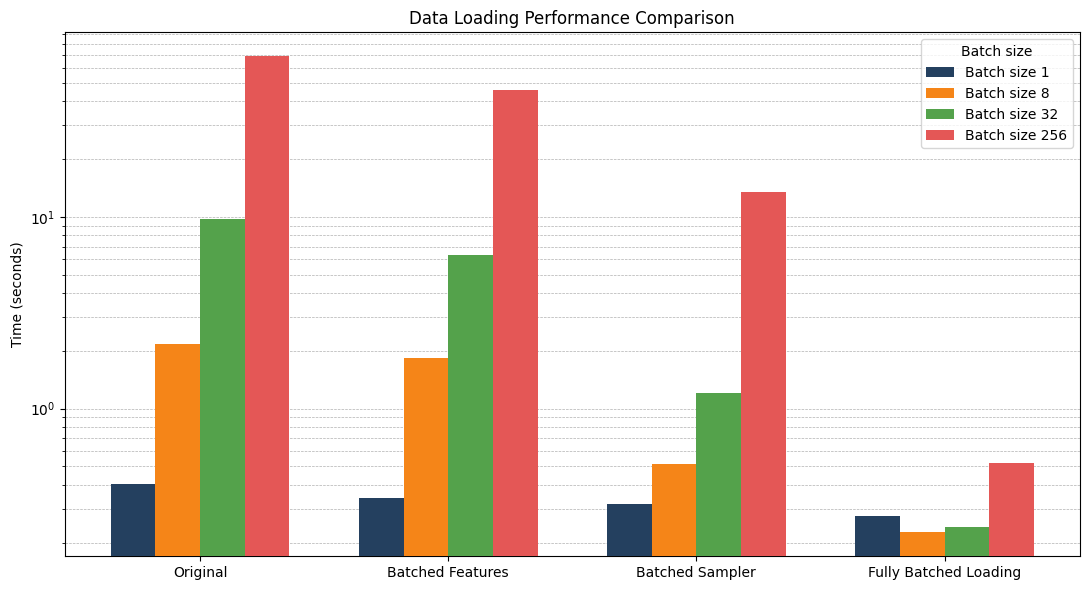

In [426]:
batch_sizes = [1, 8, 32, 256]
method_names = ["Original", "Batched Features", "Batched Sampler", "Fully Batched Loading"]

# Rows are methods; columns are batch sizes.
times = np.array([
    [time_original_1, time_original_8, time_original_32, time_original_256],
    [time_batching_1, time_batching_8, time_batching_32, time_batching_256],
    [time_sampler_1, time_sampler_8, time_sampler_32, time_sampler_256],
    [time_full_1, time_full_8, time_full_32, time_full_256],
])

x = np.arange(len(method_names))
bar_width = 0.18
colors = ["#24405F", "#F58518", "#54A24B", "#E45756"]

fig, ax = plt.subplots(figsize=(11, 6))
for offset, batch_size, color in zip(
    (np.arange(len(batch_sizes)) - 1.5) * bar_width,
    batch_sizes,
    colors,
):
    ax.bar(x + offset, times[:, batch_sizes.index(batch_size)], bar_width,
           label=f"Batch size {batch_size}", color=color, zorder=3)

ax.set_ylabel("Time (seconds)")
ax.set_title("Data Loading Performance Comparison")
ax.set_xticks(x)
ax.set_xticklabels(method_names, rotation=0, ha="center")
ax.set_yscale("log")
ax.legend(title="Batch size")
ax.grid(visible=True, which="both", axis="y", linestyle="--", linewidth=0.5)
fig.tight_layout()
plt.show()

In [429]:
time_original_1/time_full_1, time_full_8/time_full_1, time_full_32/time_full_1, time_full_256/time_full_1

(1.4581723250203902,
 0.8181334588637771,
 0.8713476762211199,
 1.8828937181324243)

In [122]:
A = {}
A.setdefault(3, []).append((3 , 5))
A.setdefault(3, []).append((2, 7))

In [125]:
for key, value in A.items():
    print(f"Key: {key}, Value: {value}")

Key: 3, Value: [(3, 5), (2, 7)]


In [318]:
file = h5py.File(h5_files[3], 'r')
indices = np.sort(np.random.randint(0, 100000, size=20))

In [323]:
file["truth"]["pt"][100:120]

array([      nan, 46308.93 , 42124.36 , 38847.285, 13799.772, 20231.475,
       21396.04 ,       nan, 46146.246, 44298.28 , 41951.156, 42483.195,
       38142.15 , 30251.068, 44395.16 , 41347.793, 24546.955, 51449.598,
       22126.977, 26281.418], dtype=float32)

In [169]:
rows = {
    name: file[name][indices]
    for name in ("egammas", "cells", "tracks")
    }

In [63]:
np.searchsorted([0, 10, 50, 192, 20913, 2939103], 25, side="right") - 1

np.int64(1)

In [44]:
dataset = H5EgammaDataset(
    h5_files,
    y_source="truth",
    y_field="pt",
    exclude_fields={"truthType", "truthOrigin", "maxEcell_onlId"},
)

loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=0)
X_batch, y_batch = next(iter(loader))

print(f"Dataset size: {len(dataset)}")
print(f"X batch shape: {X_batch.shape}")
print(f"y batch shape: {y_batch.shape}")

# The target can instead come from an eventwise field:
#event_target_dataset = H5EgammaDataset(
#    h5_files,
#    y_source="eventwise",
#    y_field="nEgammas",
#)
#_, eventwise_target = event_target_dataset[0]
#print(f"Example eventwise target: {eventwise_target.item()}")

Dataset size: 2728903
X batch shape: torch.Size([32, 6955])
y batch shape: torch.Size([32])


In [45]:
file = h5py.File(h5_path, 'r')
file.keys()

<KeysViewHDF5 ['cells', 'egammas', 'eventwise', 'tracks', 'truth']>

In [46]:
len(file['truth']['pt'][:])*0.8

311604.0

In [47]:
arr = np.array(file['egammas'][:])

In [48]:
# LightGBM needs a plain 2D feature matrix, so stack the structured fields into columns.
feature_names = [
    name for name in arr.dtype.names
    if name not in {'truthType', 'truthOrigin', 'maxEcell_onlId'}
]

X = np.column_stack([arr[name] for name in feature_names]).astype(np.float32, copy=False)
y = (file['truth']['pt'][:] / 1000.0).astype(np.float32, copy=False)

split_idx = int(0.8 * len(X))

data_train = lgbm.Dataset(X[:split_idx], label=y[:split_idx], feature_name=feature_names)
data_valid = lgbm.Dataset(X[split_idx:], label=y[split_idx:], feature_name=feature_names)

print(f'X shape: {X.shape}, y shape: {y.shape}')
print(f'Train rows: {split_idx}, validation rows: {len(X) - split_idx}')

X shape: (389505, 44), y shape: (389505,)
Train rows: 311604, validation rows: 77901


In [49]:
param_regression = {
    'objective': 'regression',
    'metric': 'rmse',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': 0
}

In [50]:
model_binary = lgbm.train(param_regression, data_train, valid_sets=[data_valid], valid_names=["val"], num_boost_round=5000, callbacks=[early_stopping(stopping_rounds=100)])

Training until validation scores don't improve for 100 rounds
Early stopping, best iteration is:
[628]	val's rmse: 6.61706


In [51]:
predictions = model_binary.predict(X[split_idx:], num_iteration=model_binary.best_iteration)

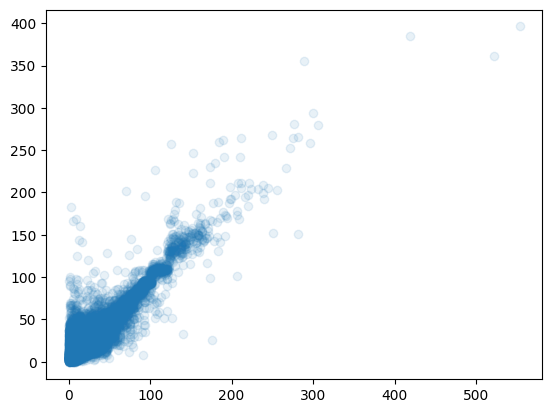

In [52]:
plt.plot(y[split_idx:], predictions, 'o', alpha=0.1)

In [53]:
file['egammas']['pt']

array([10345.689, 37026.64 , 34271.656, ..., 41587.06 , 33894.664,
       32172.168], shape=(389505,), dtype=float32)

In [54]:
file['truth']['pt']

array([10743.633, 36470.574, 33656.637, ..., 43181.105, 35677.793,
       31051.303], shape=(389505,), dtype=float32)

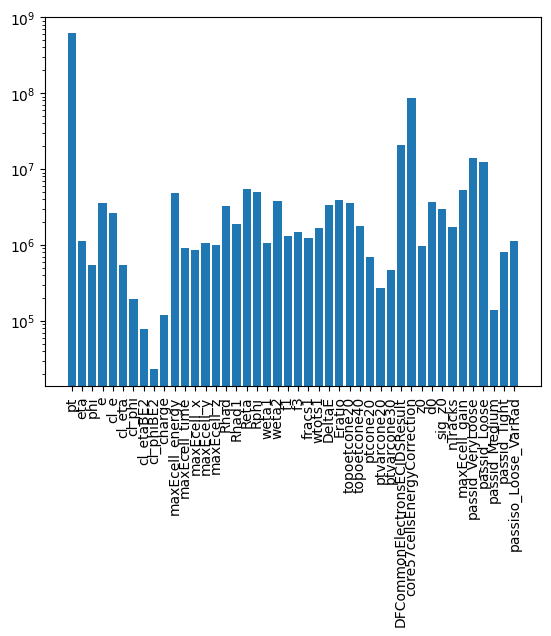

In [55]:
gain = model_binary.feature_importance(importance_type='gain', iteration=model_binary.best_iteration)
plt.bar(data_train.feature_name, gain)
plt.xticks(rotation=90)
plt.yscale('log')
plt.show()

In [56]:
data_train.feature_name[0]

'pt'

In [57]:
dataset = H5EgammaDataset(
    h5_files,
    y_source="truth",
    y_field="pt",
    exclude_fields={"truthType", "truthOrigin", "maxEcell_onlId"},
)

loader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=0)
X_batch, y_batch = next(iter(loader))

print(f"Dataset size: {len(dataset)}")
print(f"X batch shape: {X_batch.shape}")
print(f"y batch shape: {y_batch.shape}")

# The target can instead come from an eventwise field:
event_target_dataset = H5EgammaDataset(
    h5_files,
    y_source="eventwise",
    y_field="nEgammas",
)
_, eventwise_target = event_target_dataset[0]
print(f"Example eventwise target: {eventwise_target.item()}")

Dataset size: 2728903
X batch shape: torch.Size([32, 6955])
y batch shape: torch.Size([32])
Example eventwise target: 1.0


In [407]:
file["eventwise"]["nEgammas"]

array([2, 1, 4, ..., 1, 2, 1], shape=(399265,), dtype=uint64)

In [413]:
comparison_kwargs = {
    "y_source": "eventwise",
    "y_field": "nEgammas",
    "exclude_fields": {"truthType", "truthOrigin", "maxEcell_onlId"},
}
batched_dataset = H5EgammaDataset_batched(h5_files, **comparison_kwargs)
fully_batched_dataset = H5EgammaDataset_fully_batched(h5_files, **comparison_kwargs)

def compare_results(first_results, second_results):
    for position, (first, second) in enumerate(zip(first_results, second_results)):
        first_features, first_target = first
        second_features, second_target = second
        features_equal = torch.allclose(first_features, second_features, equal_nan=True)
        targets_equal = torch.allclose(first_target, second_target, equal_nan=True)
        if not features_equal or not targets_equal:
            finite_difference = torch.abs(first_features - second_features)
            finite_difference = finite_difference[torch.isfinite(finite_difference)]
            max_feature_difference = finite_difference.max().item() if len(finite_difference) else 0.0
            print(
                f"First mismatch at position {position}: "
                f"features_equal={features_equal}, "
                f"targets_equal={targets_equal}, "
                f"max_finite_feature_difference={max_feature_difference}, "
                f"targets=({first_target.item()}, {second_target.item()})"
            )
            return False
    return True

indices_to_check = [0, 1, 2, 100, len(batched_dataset) - 2, len(batched_dataset) - 1]
item_results = [
    (batched_dataset[index], fully_batched_dataset[index])
    for index in indices_to_check
]
print(f"Item-wise equal, treating matching NaNs as equal: {compare_results([first for first, _ in item_results], [second for _, second in item_results])}")

contiguous_indices = list(range(100, 132))
contiguous_batched = batched_dataset.__getitems__(contiguous_indices)
contiguous_fully_batched = fully_batched_dataset.__getitems__(contiguous_indices)
print(f"Contiguous batch equal, treating matching NaNs as equal: {compare_results(contiguous_batched, contiguous_fully_batched)}")

sparse_indices = [0, 1000, 2000, 3000, 4000, 5000, 6000, 7000]
try:
    sparse_batched = batched_dataset.__getitems__(sparse_indices)
    sparse_fully_batched = fully_batched_dataset.__getitems__(sparse_indices)
    print(f"Sparse batch equal, treating matching NaNs as equal: {compare_results(sparse_batched, sparse_fully_batched)}")
except Exception as error:
    print(f"Sparse fully-batched call failed: {type(error).__name__}: {error}")

Item-wise equal, treating matching NaNs as equal: True
Contiguous batch equal, treating matching NaNs as equal: True
Sparse batch equal, treating matching NaNs as equal: True
